In [1]:
# Install and import necessary NLP and visualization libraries
!pip install nltk pandas scikit-learn matplotlib seaborn -q
import nltk
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries, dependencies, and visualization tools loaded successfully!")

Libraries, dependencies, and visualization tools loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [2]:
# Create a sample dataset representing comments across videos
data = {
    'Comment_ID': ['YT01', 'YT02', 'YT03', 'YT04', 'YT05', 'YT06', 'YT07', 'YT08'],
    'Video_Title': ['Python NLP Tutorial', 'Python NLP Tutorial', 'Advanced Machine Learning', 'Advanced Machine Learning', 'Python NLP Tutorial', 'Advanced Machine Learning', 'Python NLP Tutorial', 'Advanced Machine Learning'],
    'Likes': [45, 12, 89, 3, 23, 150, 67, 10],
    'Comment_Text': [
        "This tutorial explained transformers and BERT so clearly! Best explanation on YouTube.",
        "The audio quality in the middle of the video was way too low, hard to hear.",
        "Can you please make a dedicated video on deploying PyTorch models to AWS?",
        "Too fast paced and skipped over too many details. Very confusing for beginners.",
        "Amazing walkthrough of tokenization and lemmatization. Subscribed!",
        "Incredible depth and practical code examples. This solved my exact project issue!",
        "Please do a follow-up video covering fine-tuning large language models.",
        "The code repository link in the description is broken and gives a 404 error."
    ]
}

df = pd.DataFrame(data)
df.head()

,Comment_ID,Video_Title,Likes,Comment_Text
0,YT01,Python NLP Tutorial,45,This tutorial explained transformers and BERT ...
1,YT02,Python NLP Tutorial,12,The audio quality in the middle of the video w...
2,YT03,Advanced Machine Learning,89,Can you please make a dedicated video on deplo...
3,YT04,Advanced Machine Learning,3,Too fast paced and skipped over too many detai...
4,YT05,Python NLP Tutorial,23,Amazing walkthrough of tokenization and lemmat...


In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase text
    text = text.lower()
    # 2. Remove HTML tags and URLs
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenization, Stopword Removal, & Lemmatization
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return " ".join(cleaned_tokens)

# Apply preprocessing
df['Cleaned_Comment'] = df['Comment_Text'].apply(preprocess_text)
df[['Comment_ID', 'Comment_Text', 'Cleaned_Comment']]

,Comment_ID,Comment_Text,Cleaned_Comment
0,YT01,This tutorial explained transformers and BERT ...,tutorial explained transformer bert clearly be...
1,YT02,The audio quality in the middle of the video w...,audio quality middle video way low hard hear
2,YT03,Can you please make a dedicated video on deplo...,please make dedicated video deploying pytorch ...
3,YT04,Too fast paced and skipped over too many detai...,fast paced skipped many detail confusing beginner
4,YT05,Amazing walkthrough of tokenization and lemmat...,amazing walkthrough tokenization lemmatization...
5,YT06,Incredible depth and practical code examples. ...,incredible depth practical code example solved...
6,YT07,Please do a follow-up video covering fine-tuni...,please followup video covering finetuning larg...
7,YT08,The code repository link in the description is...,code repository link description broken give e...


In [4]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Comment_Text'].apply(get_sentiment)
df['Compound_Score'] = df['Comment_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df[['Comment_ID', 'Sentiment', 'Compound_Score', 'Comment_Text']]

,Comment_ID,Sentiment,Compound_Score,Comment_Text
0,YT01,Positive,0.8505,This tutorial explained transformers and BERT ...
1,YT02,Negative,-0.3612,The audio quality in the middle of the video w...
2,YT03,Positive,0.6486,Can you please make a dedicated video on deplo...
3,YT04,Negative,-0.2944,Too fast paced and skipped over too many detai...
4,YT05,Positive,0.6239,Amazing walkthrough of tokenization and lemmat...
5,YT06,Positive,0.3382,Incredible depth and practical code examples. ...
6,YT07,Positive,0.3182,Please do a follow-up video covering fine-tuni...
7,YT08,Negative,-0.7003,The code repository link in the description is...


/tmp/ipykernel_1947/999634340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='Set2', order=['Positive', 'Neutral', 'Negative'])


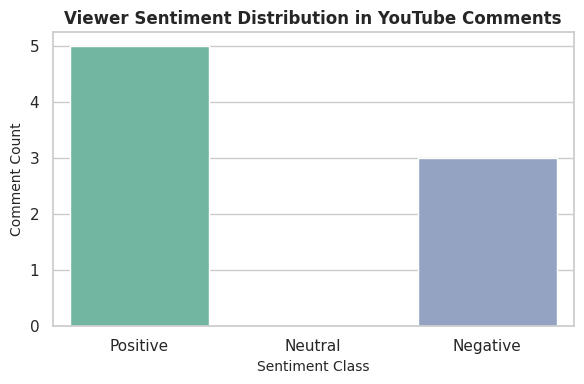

In [5]:
# Visualize sentiment breakdown of viewer comments
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', palette='Set2', order=['Positive', 'Neutral', 'Negative'])
plt.title('Viewer Sentiment Distribution in YouTube Comments', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=10)
plt.ylabel('Comment Count', fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# Vectorize text using TF-IDF for Topic Modeling
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Comment'])

# Fit Latent Dirichlet Allocation (LDA) to extract viewer discussion themes & interests
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(tfidf_matrix)

# Display top keywords per topic
feature_names = tfidf_vectorizer.get_feature_names_out()
print("=== Discovered Viewer Interest Topics (LDA Model) ===")
for topic_idx, topic in enumerate(lda_model.components_):
    top_keywords = [feature_names[i] for i in topic.argsort()[:-4:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_keywords)}")

=== Discovered Viewer Interest Topics (LDA Model) ===
Topic 1: code, subscribed, walkthrough
Topic 2: way, quality, middle
Topic 3: model, video, paced


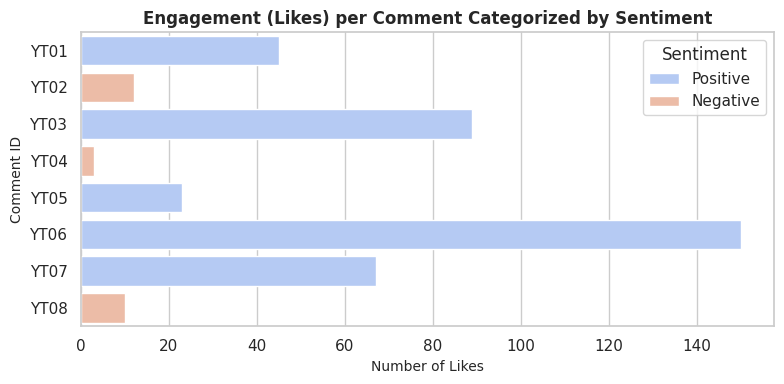

In [7]:
# Visualize engagement (likes) tied to viewer sentiments
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Likes', y='Comment_ID', hue='Sentiment', dodge=False, palette='coolwarm')
plt.title('Engagement (Likes) per Comment Categorized by Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Number of Likes', fontsize=10)
plt.ylabel('Comment ID', fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# Summary metrics and recommendations
print("=== Content Creator Analytics Report ===")
print(f"Total Comments Analyzed: {len(df)}")
print(f"Positive Engagement Ratio: {(len(df[df['Sentiment'] == 'Positive']) / len(df)) * 100:.1f}%\n")

print("=== Actionable Content Strategy & Recommendations ===")
print("1. Content Requests: Viewers are actively requesting follow-up tutorials on PyTorch deployment and LLM fine-tuning.")
print("2. Quality & Editing Control: Address feedback regarding audio levels and pacing in future videos.")
print("3. Resource Maintenance: Verify that code repository links in video descriptions are active to prevent 404 errors.")

# Final dataframe view
df[['Comment_ID', 'Video_Title', 'Likes', 'Sentiment', 'Comment_Text']]

=== Content Creator Analytics Report ===
Total Comments Analyzed: 8
Positive Engagement Ratio: 62.5%

=== Actionable Content Strategy & Recommendations ===
1. Content Requests: Viewers are actively requesting follow-up tutorials on PyTorch deployment and LLM fine-tuning.
2. Quality & Editing Control: Address feedback regarding audio levels and pacing in future videos.
3. Resource Maintenance: Verify that code repository links in video descriptions are active to prevent 404 errors.


,Comment_ID,Video_Title,Likes,Sentiment,Comment_Text
0,YT01,Python NLP Tutorial,45,Positive,This tutorial explained transformers and BERT ...
1,YT02,Python NLP Tutorial,12,Negative,The audio quality in the middle of the video w...
2,YT03,Advanced Machine Learning,89,Positive,Can you please make a dedicated video on deplo...
3,YT04,Advanced Machine Learning,3,Negative,Too fast paced and skipped over too many detai...
4,YT05,Python NLP Tutorial,23,Positive,Amazing walkthrough of tokenization and lemmat...
5,YT06,Advanced Machine Learning,150,Positive,Incredible depth and practical code examples. ...
6,YT07,Python NLP Tutorial,67,Positive,Please do a follow-up video covering fine-tuni...
7,YT08,Advanced Machine Learning,10,Negative,The code repository link in the description is...
